# Brain Tumor MRI Classification\n\nIn this notebook, we will:\n1. Load the dataset.\n2. Explore class distributions.\n3. Visualize sample MRI images.\n4. Preprocess the images.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [12]:
# Define the paths to the dataset splits
dataset_dir = 'Tumour Dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'valid')
test_dir = os.path.join(dataset_dir, 'test')

# Define image parameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard size for many CNNs and transfer learning models

# Load the datasets using TensorFlow
print("Loading Training Dataset:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Validation Dataset:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Test Dataset:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False, # We usually don't shuffle test data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Extract class names
class_names = train_dataset.class_names
print("\nClass Names:", class_names)

Loading Training Dataset:
Found 1695 files belonging to 4 classes.

Loading Validation Dataset:
Found 502 files belonging to 4 classes.

Loading Test Dataset:
Found 246 files belonging to 4 classes.

Class Names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [13]:
# Create a Preprocessing and Data Augmentation Pipeline
# We group these layers together using the Keras Sequential API.
# This pipeline will become the very first part of our custom CNN model.

from tensorflow.keras import layers, Sequential

data_augmentation = Sequential([
    # 1. Advanced Preprocessing: Normalize pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # 2. Data Augmentation: Randomly flip images horizontally
    layers.RandomFlip("horizontal"),
    
    # 3. Data Augmentation: Randomly rotate images by up to 10%
    layers.RandomRotation(0.1),
    
    # 4. Data Augmentation: Randomly zoom into images by up to 10%
    layers.RandomZoom(0.1)
])

print("Preprocessing and Data Augmentation pipeline created successfully!")

Preprocessing and Data Augmentation pipeline created successfully!


In [14]:
# Build the Custom CNN Model
num_classes = len(class_names) # We have 4 classes (Pituitary, Meningioma, Glioma, No Tumor)

model = Sequential([
    # 1. Start with our Data Augmentation and Preprocessing block
    data_augmentation,
    
    # 2. First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 3. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 4. Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 5. Flatten the feature maps into a 1D array
    layers.Flatten(),
    
    # 6. Dense (Fully Connected) Layers
    layers.Dense(128, activation='relu'),
    
    # 7. Dropout Layer (Randomly turns off 50% of neurons to prevent overfitting)
    layers.Dropout(0.5),
    
    # 8. Output Layer (1 neuron per class, no activation because we use from_logits=True in loss function)
    layers.Dense(num_classes)
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Display the model architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/30


d:\Projects\brain tumor MRI classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5097 - loss: 1.2244

53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 325ms/step - accuracy: 0.5097 - loss: 1.2244 - val_accuracy: 0.6355 - val_loss: 0.8947
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.6755 - loss: 0.8474

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.6755 - loss: 0.8474 - val_accuracy: 0.7590 - val_loss: 0.6285
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.7074 - loss: 0.7556

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 307ms/step - accuracy: 0.8177 - loss: 0.4864 - val_accuracy: 0.8466 - val_loss: 0.4075
Epoch 10/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.8383 - loss: 0.4567 - val_accuracy: 0.8287 - val_loss: 0.4575
Epoch 11/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.8478 - loss: 0.4071 - val_accuracy: 0.8406 - val_loss: 0.4094
Epoch 12/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.8525 - loss: 0.4048 - val_accuracy: 0.7948 - val_loss: 0.5420
Epoch 13/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.8584 - loss: 0.3754

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.8584 - loss: 0.3754 - val_accuracy: 0.8446 - val_loss: 0.3877
Epoch 14/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.8572 - loss: 0.3797 - val_accuracy: 0.8586 - val_loss: 0.4225
Epoch 15/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 0.8720 - loss: 0.3480 - val_accuracy: 0.8008 - val_loss: 0.5133
Epoch 16/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8761 - loss: 0.3453

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.8761 - loss: 0.3453 - val_accuracy: 0.8685 - val_loss: 0.3538
Epoch 17/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.8596 - loss: 0.3650 - val_accuracy: 0.8426 - val_loss: 0.4473
Epoch 18/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8708 - loss: 0.3536

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.8708 - loss: 0.3536 - val_accuracy: 0.8765 - val_loss: 0.3355
Epoch 19/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.8667 - loss: 0.3421 - val_accuracy: 0.8207 - val_loss: 0.4804
Epoch 20/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8767 - loss: 0.3308

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 302ms/step - accuracy: 0.8767 - loss: 0.3308 - val_accuracy: 0.8944 - val_loss: 0.2912
Epoch 21/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 0.8879 - loss: 0.3051 - val_accuracy: 0.8924 - val_loss: 0.3585
Epoch 22/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 0.8867 - loss: 0.3054 - val_accuracy: 0.8705 - val_loss: 0.3997
Epoch 23/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 297ms/step - accuracy: 0.8909 - loss: 0.2907 - val_accuracy: 0.8805 - val_loss: 0.3363
Epoch 24/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 298ms/step - accuracy: 0.8903 - loss: 0.2659 - val_accuracy: 0.8884 - val_loss: 0.3224
Epoch 25/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 301ms/step - accuracy: 0.9015 - loss: 0.2574 - val_accuracy: 0.8745 - val_loss: 0.3820
Training completed!


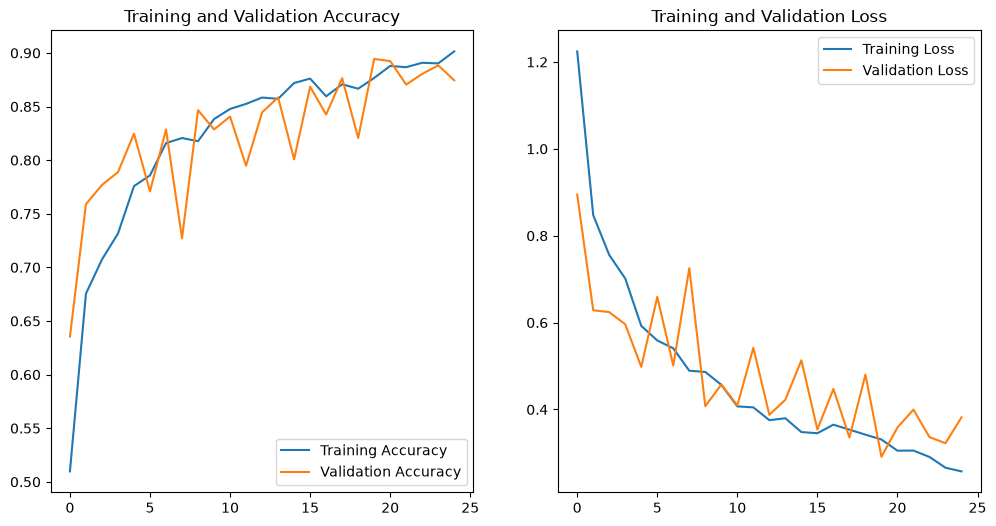

In [15]:
# Define Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. EarlyStopping: Stops training if the validation loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 2. ModelCheckpoint: Saves the best version of the model during training
model_checkpoint = ModelCheckpoint(
    'custom_cnn_model.h5', 
    monitor='val_loss', 
    save_best_only=True
)

callbacks = [early_stopping, model_checkpoint]

# Set the number of epochs (You can increase this, EarlyStopping will stop it if it converges early)
EPOCHS = 30

print("Starting training...")
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)
print("Training completed!")

# --- Visualizing the Training History ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Loading best model weights...

Evaluating on Test Dataset:
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9024 - loss: 0.2491

Final Test Accuracy: 90.24%

Generating predictions for Confusion Matrix...


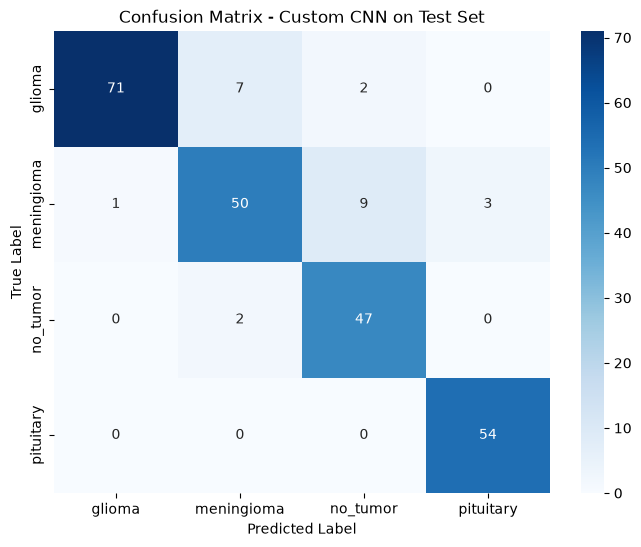


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.89      0.93        80
  meningioma       0.85      0.79      0.82        63
    no_tumor       0.81      0.96      0.88        49
   pituitary       0.95      1.00      0.97        54

    accuracy                           0.90       246
   macro avg       0.90      0.91      0.90       246
weighted avg       0.91      0.90      0.90       246



In [16]:
# --- Model Evaluation on Test Set ---
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the best saved model from the ModelCheckpoint
print("Loading best model weights...")
best_model = tf.keras.models.load_model('custom_cnn_model.h5')

# 2. Evaluate it on the completely unseen Test Dataset
print("\nEvaluating on Test Dataset:")
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# 3. Generate Predictions for the Confusion Matrix
print("\nGenerating predictions for Confusion Matrix...")
y_true = []
y_pred_probs = []

# Loop through the test dataset batches to extract true labels and get predictions
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = best_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
# Because we used from_logits=True in our loss, the outputs are raw numbers. 
# We use argmax to find the index of the highest number (which corresponds to the predicted class)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Custom CNN on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))